In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [5]:
TRAIN_DIR = "../dataset/train"

TEST_DIR  ="../dataset/test"

In [6]:
classes = os.listdir(TRAIN_DIR)

print("Classes:", classes)

Classes: ['10_rupee', '1_rupee', '2_rupee', '5_rupee']


In [7]:
# count image
for class_name in classes:
    class_path = os.path.join(TRAIN_DIR, class_name)

    images = os.listdir(class_path)

    print(f"{class_name}: {len(images)} images")

10_rupee: 120 images
1_rupee: 150 images
2_rupee: 60 images
5_rupee: 180 images


VIZUALIZE ONE IMAGE

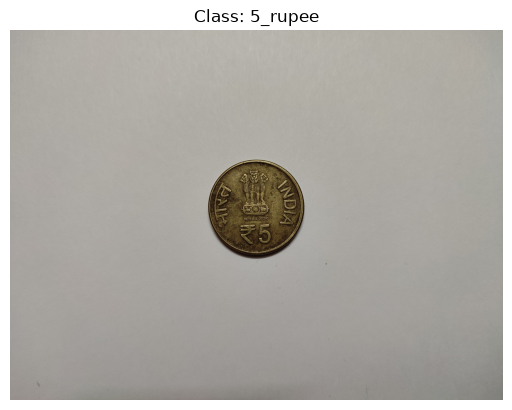

Image size: (4000, 3000)


In [8]:
class_name ="5_rupee"

class_path = os.path.join(TRAIN_DIR, class_name)

image_name = os.listdir(class_path)[0]

image_path = os.path.join(class_path, image_name)

image = Image.open(image_path)

plt.imshow(image)
plt.title(f"Class: {class_name}")
plt.axis("off")
plt.show()

print("Image size:", image.size)

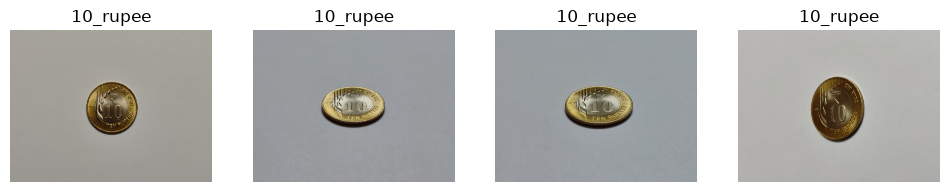

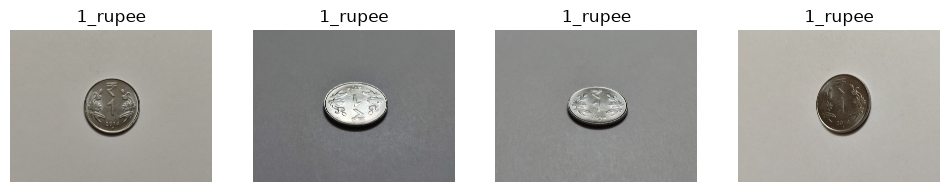

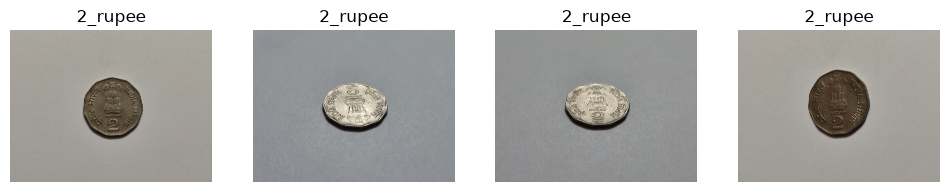

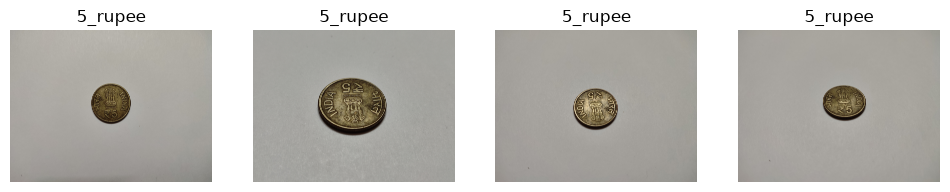

In [9]:
# Display samples from every class
for class_name in classes:

    class_path = os.path.join(TRAIN_DIR, class_name)

    image_names = os.listdir(class_path)[:4]

    plt.figure(figsize=(12, 3))

    for i, image_name in enumerate(image_names):

        image_path = os.path.join(class_path, image_name)

        image = Image.open(image_path)

        plt.subplot(1, 4, i + 1)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis("off")

    plt.show()

In [10]:
image_path = os.path.join(
    TRAIN_DIR, "5_rupee", os.listdir(os.path.join(TRAIN_DIR, "5_rupee"))[0]
)

image = Image.open(image_path)

print("Width: ", image.width)
print("Height: ", image.height)
print("IMage color: ", image.mode)

Width:  4000
Height:  3000
IMage color:  RGB


In [11]:
image_array = np.array(image)

print("Shape:", image_array.shape)
print("Data type:", image_array.dtype)
print("Minimum pixel value:", image_array.min())
print("Maximum pixel value:", image_array.max())

Shape: (3000, 4000, 3)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [12]:
train_counts = {}
test_counts = {}

for class_name in classes:

    train_path = os.path.join(TRAIN_DIR, class_name)
    test_path = os.path.join(TEST_DIR, class_name)

    train_counts[class_name] = len(os.listdir(train_path))
    test_counts[class_name] = len(os.listdir(test_path))


print("TRAIN DATA")
for class_name, count in train_counts.items():
    print(f"{class_name}: {count}")

print("\nTEST DATA")
for class_name, count in test_counts.items():
    print(f"{class_name}: {count}")

TRAIN DATA
10_rupee: 120
1_rupee: 150
2_rupee: 60
5_rupee: 180

TEST DATA
10_rupee: 30
1_rupee: 30
2_rupee: 30
5_rupee: 60


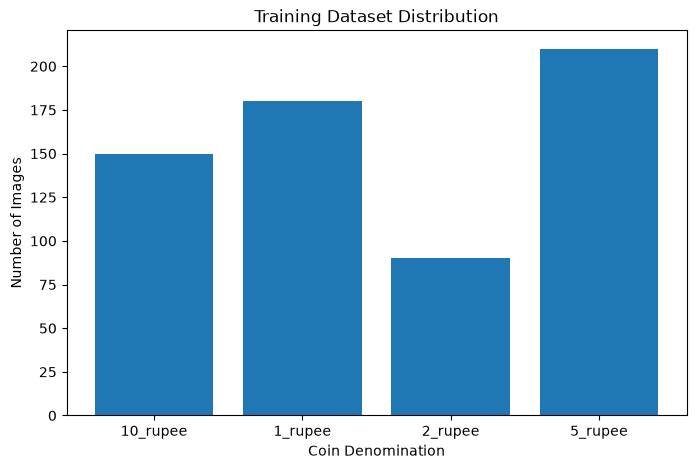

In [11]:
plt.figure(figsize=(8, 5))

plt.bar(train_counts.keys(), train_counts.values())

plt.xlabel("Coin Denomination")
plt.ylabel("Number of Images")
plt.title("Training Dataset Distribution")

plt.show()

In [13]:
IMG_SIZE = (128, 128)

image_path = os.path.join(
    TRAIN_DIR,
    "5_rupee",
    os.listdir(os.path.join(TRAIN_DIR, "5_rupee"))[0]
)

image = Image.open(image_path)

print("Original size:", image.size)

resized_image = image.resize(IMG_SIZE)

print("Resized size:", resized_image.size)

Original size: (4000, 3000)
Resized size: (128, 128)


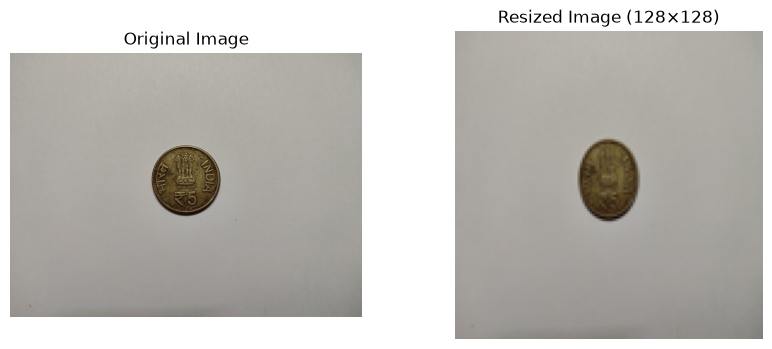

In [ ]:
################################done run this part of code #########################################################

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resized_image)
plt.title("Resized Image (128×128)")
plt.axis("off")

plt.show()

# see in this resize image the image is not properly showing so we will first crop the side part of image and again we will do resizing 

##########################################(PREPROCESSING PART)################################################

## Improved Preprocessing: Crop Before Resizing

The original images have a large amount of background around the coin.

Instead of directly resizing the complete image, we first crop the central region containing the coin and then resize it to 128 × 128.

Pipeline:

Original Image (4000 × 3000)
→ Center Crop (1600 × 1600)
→ Resize (128 × 128)
→ Normalize (0–1)

In [14]:
# Create the center crop
# Size of the square crop
CROP_SIZE = 1600

width, height = image.size

# Calculate crop boundaries
left = (width - CROP_SIZE) // 2
top = (height - CROP_SIZE) // 2
right = left + CROP_SIZE
bottom = top + CROP_SIZE

# Crop the image
cropped_image = image.crop((left, top, right, bottom))

print("Original size:", image.size)
print("Cropped size:", cropped_image.size)

Original size: (4000, 3000)
Cropped size: (1600, 1600)


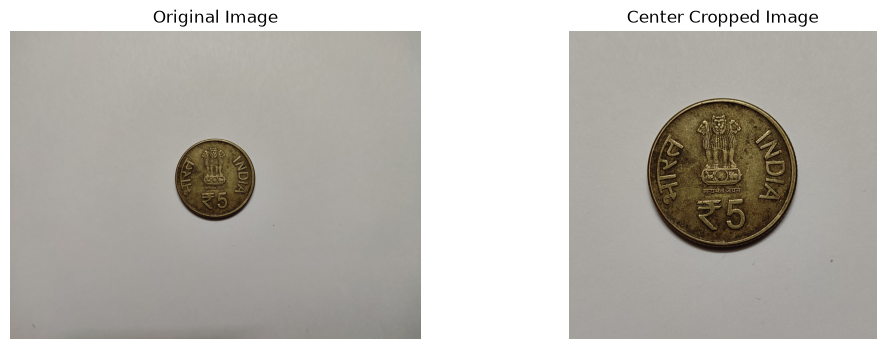

In [18]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cropped_image)
plt.title("Center Cropped Image")
plt.axis("off")

plt.show()

In [16]:
resized_cropped_image = cropped_image.resize(IMG_SIZE)

print("Cropped size:", cropped_image.size)
print("Final size:", resized_cropped_image.size)

Cropped size: (1600, 1600)
Final size: (128, 128)


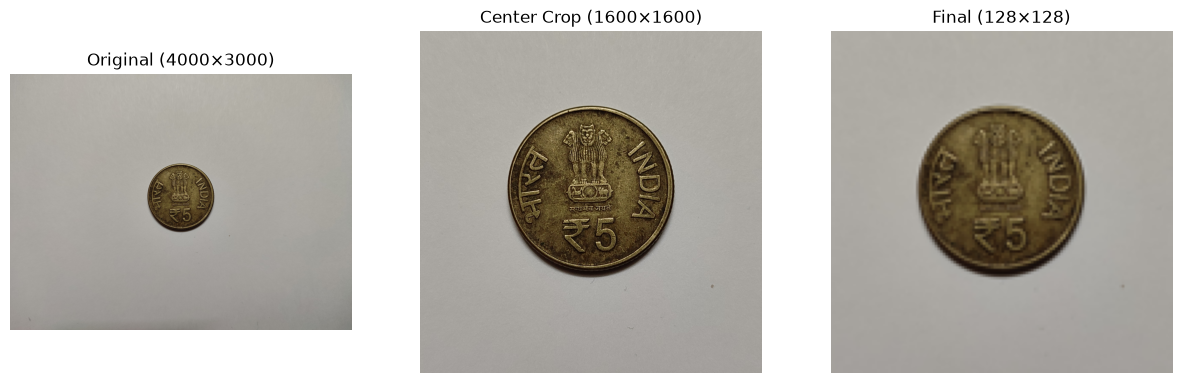

In [17]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original (4000×3000)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cropped_image)
plt.title("Center Crop (1600×1600)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(resized_cropped_image)
plt.title("Final (128×128)")
plt.axis("off")

plt.show()

In [19]:
processed_array = np.array(resized_cropped_image)

print("Shape:", processed_array.shape)
print("Data type:", processed_array.dtype)
print("Min:", processed_array.min())
print("Max:", processed_array.max())

Shape: (128, 128, 3)
Data type: uint8
Min: 4
Max: 187


In [20]:
processed_array = processed_array / 255.0

print("Shape:", processed_array.shape)
print("Data type:", processed_array.dtype)
print("Min:", processed_array.min())
print("Max:", processed_array.max())

Shape: (128, 128, 3)
Data type: float64
Min: 0.01568627450980392
Max: 0.7333333333333333


In [21]:
# Convert the resized cropped image to a NumPy array
final_array = np.array(resized_cropped_image)

print("Before normalization")
print("Shape:", final_array.shape)
print("Data type:", final_array.dtype)
print("Min:", final_array.min())
print("Max:", final_array.max())


# Normalize pixel values from 0-255 to 0-1
final_normalized = final_array.astype(np.float32) / 255.0

print("\nAfter normalization")
print("Shape:", final_normalized.shape)
print("Data type:", final_normalized.dtype)
print("Min:", final_normalized.min())
print("Max:", final_normalized.max())

Before normalization
Shape: (128, 128, 3)
Data type: uint8
Min: 4
Max: 187

After normalization
Shape: (128, 128, 3)
Data type: float32
Min: 0.015686275
Max: 0.73333335


In [22]:
resized_array = np.array(resized_image)

print("Shape:", resized_array.shape)
print("Data type:", resized_array.dtype)
print("Min:", resized_array.min())
print("Max:", resized_array.max())

Shape: (128, 128, 3)
Data type: uint8
Min: 9
Max: 188


In [23]:
normalized_array = resized_array / 255.0

print("Shape:", normalized_array.shape)
print("Data type:", normalized_array.dtype)
print("Min:", normalized_array.min())
print("Max:", normalized_array.max())

Shape: (128, 128, 3)
Data type: float64
Min: 0.03529411764705882
Max: 0.7372549019607844


###################################################(TRAIN TEST VALIDATION SPLIT)#######################################
The dataset contains multiple images of the same physical coin under different lighting conditions.

To avoid data leakage, validation images should come from different physical coin groups than the training images.

Therefore, we will split at the physical coin level rather than randomly splitting individual images.

In [24]:
ORIGINAL_DATASET_DIR = r"C:/Users/anujk/Downloads/archive/DataSet"

coin_classes = ["One", "Two", "Five", "Ten"]

for class_name in coin_classes:

    class_path = os.path.join(ORIGINAL_DATASET_DIR, class_name)

    coin_groups = [
        folder for folder in os.listdir(class_path)
        if os.path.isdir(os.path.join(class_path, folder))
    ]

    print(f"{class_name}:")
    print("Coin groups:", coin_groups)
    print("Number of coin groups:", len(coin_groups))
    print()

One:
Coin groups: ['Coin 1', 'Coin 2', 'Coin 3', 'Coin 4', 'Coin 5', 'Coin 6', 'Coin 7']
Number of coin groups: 7

Two:
Coin groups: ['Coin 1', 'Coin 2', 'Coin 3', 'Coin 4']
Number of coin groups: 4

Five:
Coin groups: ['Coin 1', 'Coin 2', 'Coin 3', 'Coin 4', 'Coin 5', 'Coin 6', 'Coin 7', 'Coin 8', 'Coin 9']
Number of coin groups: 9

Ten:
Coin groups: ['Coin 1', 'Coin 2', 'Coin 3', 'Coin 4', 'Coin 5', 'Coin 6']
Number of coin groups: 6



## Data Augmentation

Data augmentation artificially creates variations of training images.

It helps the CNN generalize better to images that are slightly different from the images seen during training.

For MudraVision AI:

- Rotation → useful
- Zoom → useful
- Translation → useful
- Horizontal flip → avoided because coin text and symbols would become mirrored

Augmentation is applied only to the training dataset.

In [ ]:
# %pip install tensorflow

  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.36.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.4.0-cp312-cp312-win_amd64.whl.metadata (7.6 kB)
  Using cached grpcio-1.83.1-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached keras-3.15.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached h5py


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import tensorflow as tf
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )
])

data_augmentation

<Sequential name=sequential, built=False>

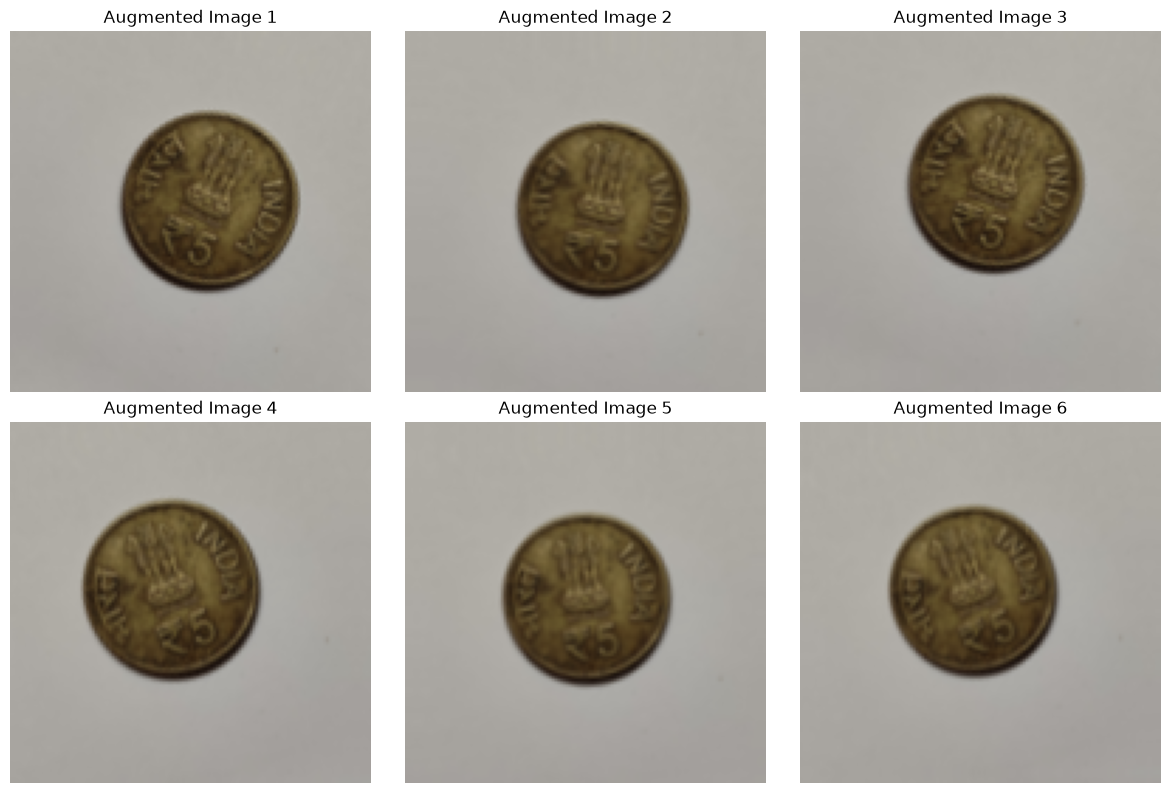

In [25]:
import numpy as np
sample_image = np.array(resized_cropped_image).astype(np.float32) / 255.0

sample_batch = tf.expand_dims(sample_image, axis=0)

plt.figure(figsize=(12, 8))

for i in range(6):

    augmented_image = data_augmentation(sample_batch, training=True)

    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented_image[0])
    plt.title(f"Augmented Image {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Loading the Dataset with TensorFlow

We now load the training, validation, and test images into TensorFlow datasets.

Training data is used to learn the CNN.

Validation data is used during training to monitor generalization.

Test data is kept separate and will only be used for final evaluation.

Images will be resized to 128 × 128 pixels and grouped into batches.

In [26]:
import tensorflow as tf

TRAIN_DIR = "../dataset/train"
VALIDATION_DIR = "../dataset/validation"
TEST_DIR = "../dataset/test"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32 #instead of 510 it will process 32 image at a time
SEED = 42

In [28]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, 
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle =True,
    seed = SEED
)

Found 510 files belonging to 4 classes.


In [39]:
validation_ds = tf.keras.utils.image_dataset_from_directory(
    VALIDATION_DIR,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle= False
)

Found 120 files belonging to 4 classes.


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = False
)

Found 150 files belonging to 4 classes.


## Final Image Preprocessing Pipeline

Each image will go through the following preprocessing steps:

Original Image
→ Center Crop
→ Resize to 128 × 128
→ Normalize pixel values to 0–1

In [43]:
IMG_SIZE = (128, 128)
CROP_SIZE = 1600

def preprocess_image(image, label):

    # Get original image dimensions
    height = tf.shape(image)[0]
    width = tf.shape(image)[1]

    # Calculate center crop position
    left = (width - CROP_SIZE) // 2
    top = (height - CROP_SIZE) // 2

    # Center crop
    image = tf.image.crop_to_bounding_box(
        image,
        top,
        left,
        CROP_SIZE,
        CROP_SIZE
    )

    # Resize
    image = tf.image.resize(image, IMG_SIZE)

    # Normalize pixels from 0-255 to 0-1
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [44]:
import pathlib

def get_image_paths_and_labels(directory):
    
    directory = pathlib.Path(directory)
    
    image_paths = []
    labels = []
    
    for class_index, class_name in enumerate(class_names):
        
        class_dir = directory / class_name
        
        for image_path in class_dir.iterdir():
            
            if image_path.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]:
                image_paths.append(str(image_path))
                labels.append(class_index)
    
    return image_paths, labels

In [45]:
train_paths, train_labels = get_image_paths_and_labels(TRAIN_DIR)
validation_paths, validation_labels = get_image_paths_and_labels(VALIDATION_DIR)
test_paths, test_labels = get_image_paths_and_labels(TEST_DIR)

print("Training images:", len(train_paths))
print("Validation images:", len(validation_paths))
print("Test images:", len(test_paths))

Training images: 510
Validation images: 120
Test images: 150


In [46]:
def load_image(image_path, label):
    
    image = tf.io.read_file(image_path)
    
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )
    
    return image, label

In [48]:
train_raw = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

validation_raw = tf.data.Dataset.from_tensor_slices(
    (validation_paths, validation_labels)
)

test_raw = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

train_raw = train_raw.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_raw = validation_raw.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_raw = test_raw.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [49]:
# Apply preprocessing
train_processed = train_raw.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_processed = validation_raw.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_processed = test_raw.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [50]:
BATCH_SIZE = 32

train_processed = train_processed.shuffle(
    buffer_size=len(train_paths),
    seed=SEED
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

validation_processed = validation_processed.batch(
    BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)

test_processed = test_processed.batch(
    BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)

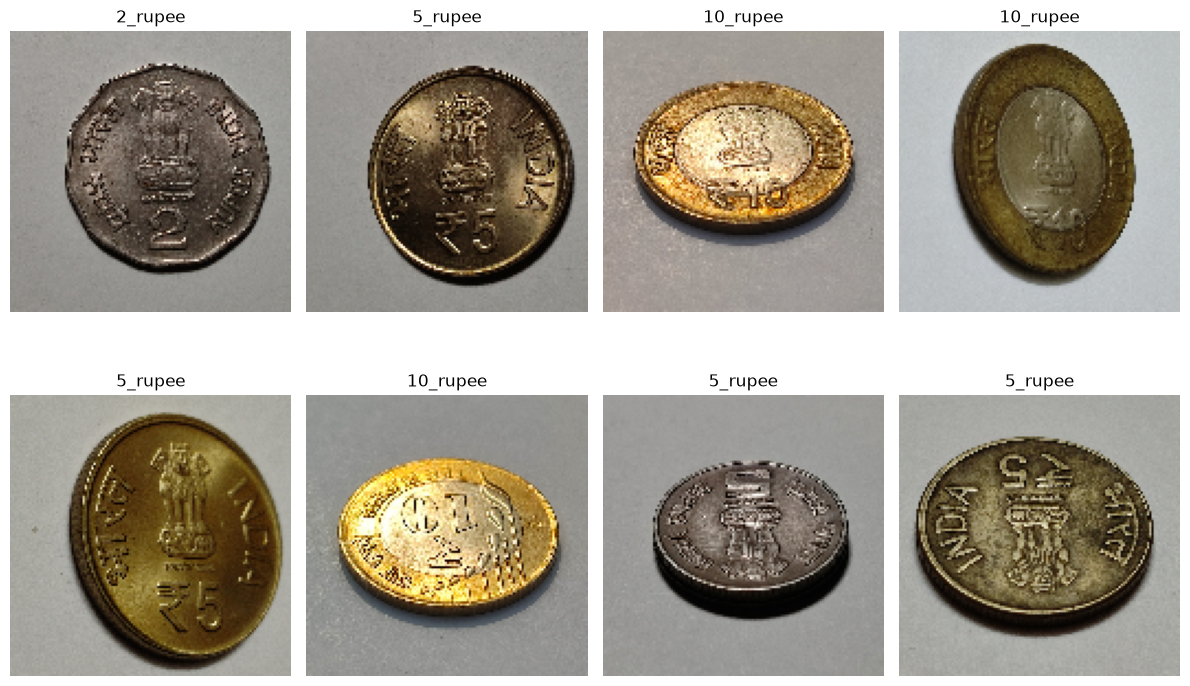

In [51]:
plt.figure(figsize=(12, 8))

for images, labels in train_processed.take(1):
    
    for i in range(8):
        
        plt.subplot(2, 4, i + 1)
        
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [53]:
# Apply data augmentation to the training batches

train_processed = train_processed.map(
    lambda images, labels: (
        data_augmentation(images, training=True),
        labels
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

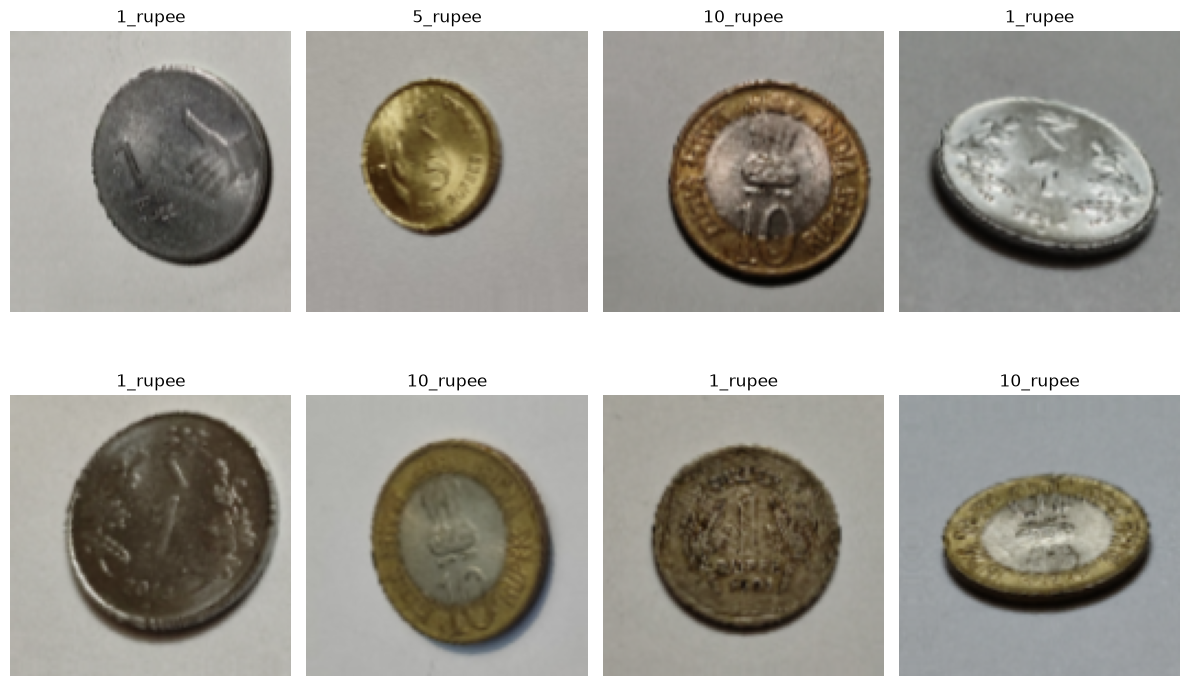

In [55]:
plt.figure(figsize=(12, 8))

for images, labels in train_processed.take(1):

    for i in range(8):

        plt.subplot(2, 4, i + 1)

        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()